<a href="https://colab.research.google.com/github/AarushMuthukrishnan/Machine-Learning-Notebooks/blob/main/3.%20Impact_of_AI_on_Students.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Impact of AI on Students**

In this notebook, we will be taking a look at the "Impact of Ai on Students" dataset, found on Kaggle. We will first do a brief EDA on the dataset, then move on to preparing the dataset, and finally testing and training different models to analyze the best fit.



# Project Overview

Our goal for this project is to train a classifier that is able to predict the level of burnout a student is at risk of based on their current academic rigor and other characteristics of the student themeselves, to a reasonable accuracy. Burnout risk levels are divided into 3 categories: Low, Medium, and High. With our model we will be looking to train, we will be able to categorize a student's risk level of burning out, with many of the influencing features being related to AI and student's usage of it.

# Setup

For this project, to keep results identical every time the code is run, a random_state will be set below to keep all outcomes universal:

In [ ]:
random_state = 67

Let's first install all the libraries needed:

In [ ]:
!pip install kaggle pandas numpy matplotlib seaborn scikit-learn

Now, let's download the dataset from Kaggle and save it locally:

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("laveshjadon/ai-impact-on-students")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'ai-impact-on-students' dataset.
Path to dataset files: /kaggle/input/ai-impact-on-students


With all our libraries installed, let's import them into our environment:

In [ ]:
import os

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OrdinalEncoder, LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

Finally, let's read in the CSV file containing the dataset and store it in a variable named *dt*:


In [ ]:
dt = pd.read_csv('/kaggle/input/ai-impact-on-students/ai_student_impact_dataset (1).csv')

# Exploratory Data Analysis

Now that we have all our libraries and our dataset loaded in, let's take a look at what we are working with here:

In [ ]:
dt

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,149996,Business,Senior,2.899,12.16,Copywriting/Drafting,Beginner,2,False,13.36,2,Allowed_With_Citation,2,3.584,66.16,High
49996,149997,STEM,Senior,2.870,2.51,Copywriting/Drafting,Intermediate,1,False,4.67,3,Actively_Encouraged,3,3.096,81.62,Medium
49997,149998,Business,Senior,3.177,15.87,Summarizing_Reading,Advanced,5,True,3.92,4,Allowed_With_Citation,5,3.605,97.21,High
49998,149999,Business,Junior,3.398,19.91,Debugging/Troubleshooting,Intermediate,5,False,7.10,5,Allowed_With_Citation,3,3.527,84.12,Medium


We can see there are many columns atrributing to many students, specifically to 50,000 of them, and their specific characteristics in education. Let's take a look at the types of data we are working with:

In [ ]:
dt.dtypes

,0
Student_ID,int64
Major_Category,object
Year_of_Study,object
Pre_Semester_GPA,float64
Weekly_GenAI_Hours,float64
Primary_Use_Case,object
Prompt_Engineering_Skill,object
Tool_Diversity,int64
Paid_Subscription,bool
Traditional_Study_Hours,float64


It seems like we have a couple of types to work with. Let's see how many of each we have to get a better understanding:

In [ ]:
dt.dtypes.value_counts()

,count
object,6
float64,5
int64,4
bool,1


We can already see that some preprocessing has to be done in order to handle those *object* and *bool* values. Let's now look into some statistics on the data itself:

In [ ]:
dt.describe()

,Student_ID,Pre_Semester_GPA,Weekly_GenAI_Hours,Tool_Diversity,Traditional_Study_Hours,Perceived_AI_Dependency,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score
count,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,125000.500000,3.146102,8.427752,2.80026,11.209271,3.505360,4.270760,3.349299,75.798125
std,14433.901067,0.478854,8.269490,1.18802,5.156426,1.820812,2.144066,0.495673,13.281626
min,100001.000000,1.183000,0.000000,1.00000,1.000000,1.000000,1.000000,1.000000,10.780000
25%,112500.750000,2.834000,2.390000,2.00000,7.560000,2.000000,3.000000,3.023750,66.820000
50%,125000.500000,3.210000,5.800000,3.00000,11.180000,3.000000,4.000000,3.421000,76.000000
75%,137500.250000,3.521000,11.720000,4.00000,14.710000,5.000000,6.000000,3.749000,85.190000
max,150000.000000,3.998000,40.000000,5.00000,35.860000,10.000000,10.000000,4.000000,100.000000


We can see many things from here, for example, the average student studies for 11 hours per week without use of AI. Also, the average pre-semester GPA was a 3.14 while the average post-semester GPA was a 3.34. This increase of a GPA can be related to many things, so let's see if we can find more about how these different data poits are correlated:

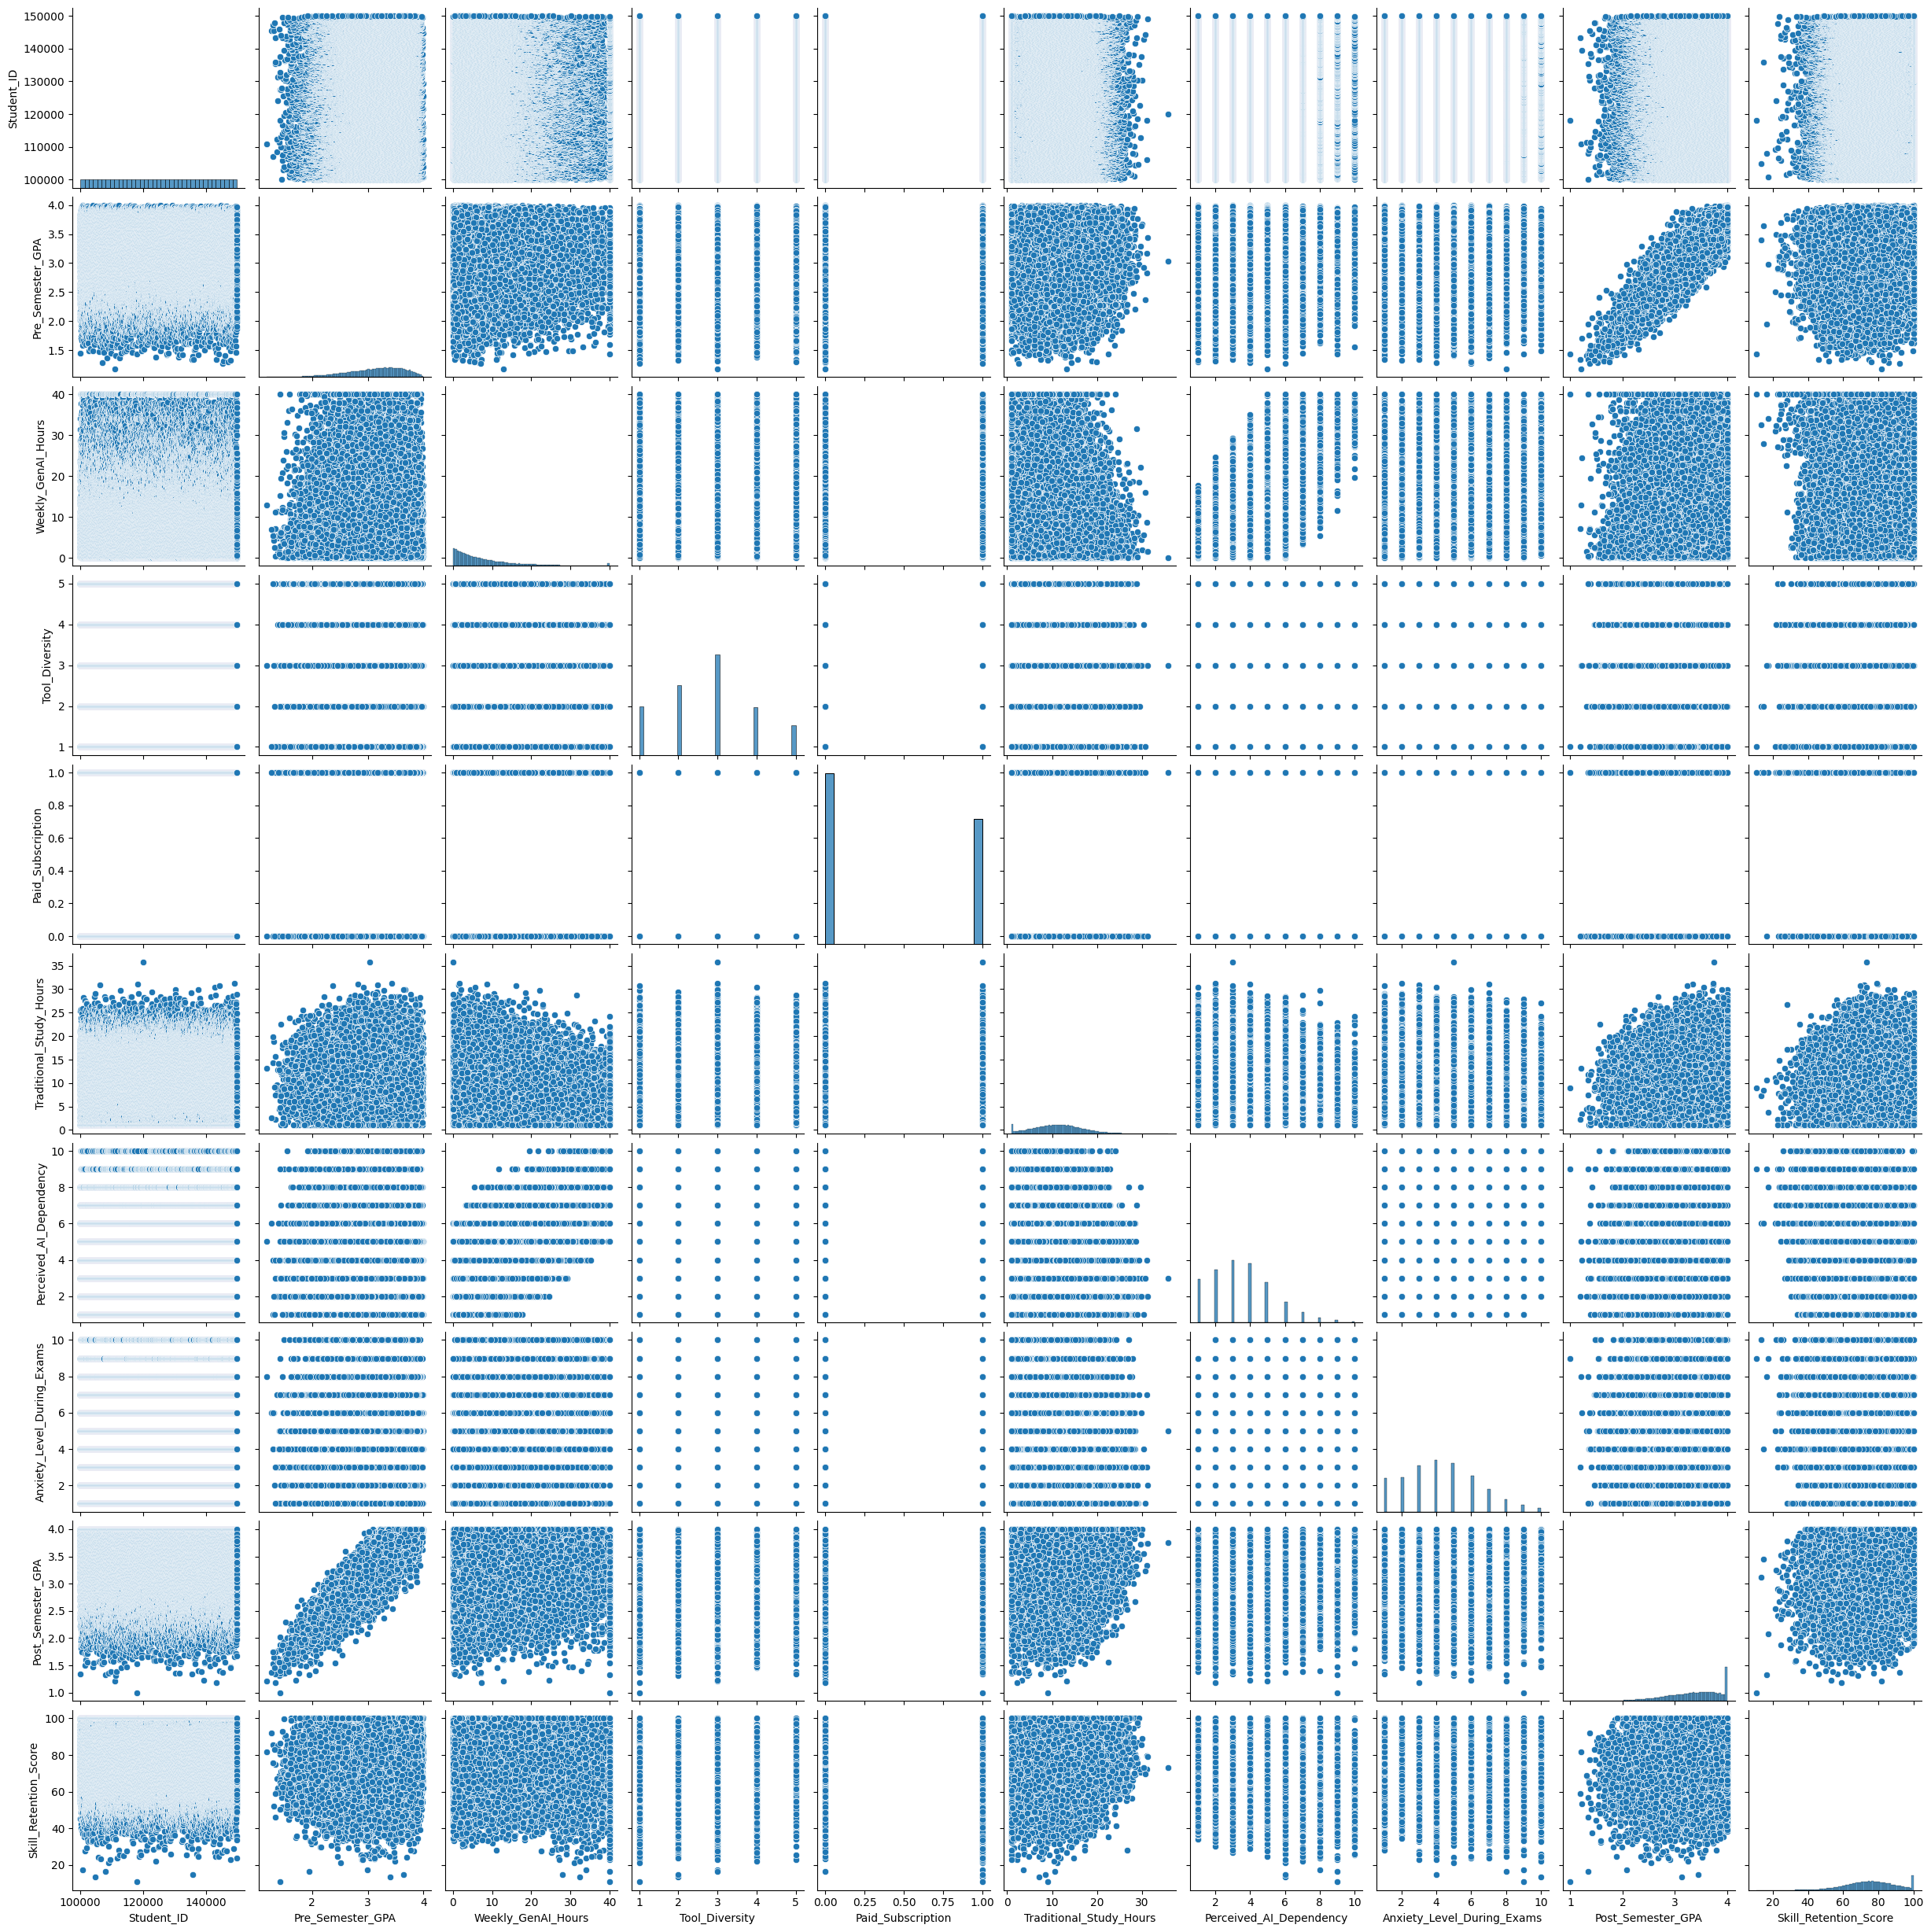

In [ ]:
sns.pairplot(dt)

Again, many things can be analyzed from this, such as

*   Traditional study hours being positivley correlated with skill retention score
*   Weekly GenAI hours being negativley correlated with traditional study hours
*   Skill retention score being positivley correlated with pre/post semester GPA

In fact, we can calculate these correlations to verify these(with each value being greater than 0 if it's positivley correlated and less than 0 when negativley correlated):





In [ ]:
print(float(dt['Traditional_Study_Hours'].corr(dt['Skill_Retention_Score'])))
print(float(dt['Weekly_GenAI_Hours'].corr(dt['Traditional_Study_Hours'])))
print(float(dt['Skill_Retention_Score'].corr(dt['Pre_Semester_GPA'])))
print(float(dt['Skill_Retention_Score'].corr(dt['Post_Semester_GPA'])))

0.14756511713957735
-0.1573678279522267
0.09901885710641782
0.16961573796778684


One important thing to look at is the distribution of our target column: *Burnout_Risk_Level*, so that when we later split our data we ensure the distribution stays the same. We can look at this through the proportion percentages:

In [ ]:
dt.Burnout_Risk_Level.value_counts(normalize=True)

,proportion
Burnout_Risk_Level,
Medium,0.42288
Low,0.32738
High,0.24974


...or we can look at it through a bar plot:

<Axes: xlabel='Burnout_Risk_Level', ylabel='count'>

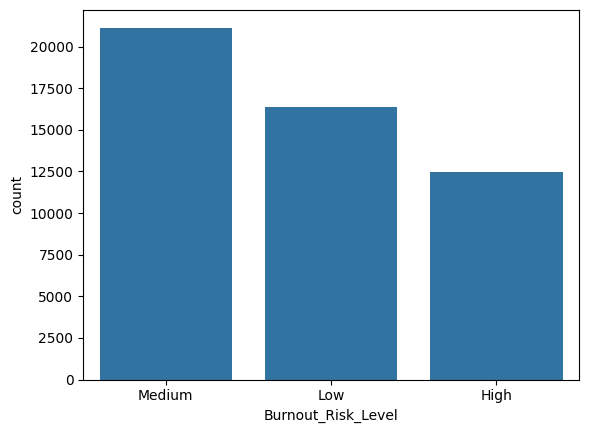

In [ ]:
sns.barplot(dt.Burnout_Risk_Level.value_counts())


Either way, we do see that the distribution is slightly unlevel, but we will ensure this is handeled by replicating this distribution in our train-test split.

# Preprocessing

Now that we have a fair understanding of our dataset, let's clean up our data and make sure it is all processed before we begin training our models. Let's first address our differing data types as identified before. Our focus is to encode all ordinal values, so let's retrieve all columns that fit this:

In [ ]:
dt.select_dtypes(["bool", "object"]).columns.to_list()


['Major_Category',
 'Year_of_Study',
 'Primary_Use_Case',
 'Prompt_Engineering_Skill',
 'Paid_Subscription',
 'Institutional_Policy',
 'Burnout_Risk_Level']

To make sure we aren't working with too many unique items per column, let's look at those for each one:

In [ ]:
for i in dt.select_dtypes(["bool", "object"]).columns.to_list():
  print(i, dt[i].unique())

Major_Category ['Humanities' 'Medical' 'Business' 'STEM' 'Arts']
Year_of_Study ['Senior' 'Junior' 'Freshman' 'Sophomore' 'Graduate']
Primary_Use_Case ['Copywriting/Drafting' 'Ideation' 'Summarizing_Reading'
 'Debugging/Troubleshooting' 'Direct_Answer_Generation']
Prompt_Engineering_Skill ['Beginner' 'Advanced' 'Intermediate']
Paid_Subscription [ True False]
Institutional_Policy ['Allowed_With_Citation' 'Strict_Ban' 'Actively_Encouraged']
Burnout_Risk_Level ['High' 'Low' 'Medium']


Although we could use different encodings for the columns who do and don't have a specific order, let's keep things simple and use one for all. *LabelEncoder* should work just fine here:

In [ ]:
le = LabelEncoder()
for i in dt.select_dtypes(["bool", "object"]).columns.to_list():
  dt[i] = le.fit_transform(dt[i])
dt

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,100001,2,3,2.418,23.31,0,1,1,1,8.13,5,1,6,2.393,86.44,0
1,100002,3,2,3.821,1.12,3,0,5,0,16.65,3,1,9,3.696,69.39,1
2,100003,1,0,3.398,21.26,4,1,2,0,10.35,5,2,9,3.499,73.93,2
3,100004,1,3,3.789,1.82,0,2,4,0,15.23,2,1,2,4.000,63.58,2
4,100005,4,4,3.635,9.29,1,0,4,0,12.55,4,1,4,3.798,100.00,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,149996,1,3,2.899,12.16,0,1,2,0,13.36,2,1,2,3.584,66.16,0
49996,149997,4,3,2.870,2.51,0,2,1,0,4.67,3,0,3,3.096,81.62,2
49997,149998,1,3,3.177,15.87,4,0,5,1,3.92,4,1,5,3.605,97.21,0
49998,149999,1,2,3.398,19.91,1,2,5,0,7.10,5,1,3,3.527,84.12,2


Now that we've made all our columns numeric, we can move into the last step before training our models. Let's first start off by defining our X and Y sets. Remeber that our target value is the burnout risk, with the rest of the columns being feature columns:

In [ ]:
X = dt[dt.columns[:-1]]
y = dt["Burnout_Risk_Level"]

Especially for some of the models we will use which require scaling, let us scale our X values using *StandardScaler*

In [ ]:
ss = StandardScaler()
X = ss.fit_transform(X)

Let's now split our dataset:

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y)

One last thing: let's verify that the distributions of the target column we saw initially still hold true for our splits:

In [ ]:
y_train.value_counts(normalize=True)

,proportion
Burnout_Risk_Level,
2,0.421627
1,0.327813
0,0.250560


# Model Training

We are now ready to begin training and testing models. For classfiers, there ar emany models available, so what we will be doing is testing each one and comparing their results. The models we will be testing are:


*   Logistic Regression
*   K Nearest Neighbors
*   Support Vector Machine(SVM)
*   Decision Tree
*   Random Forest

Note that we could stack all these models into one, but because each model itself takes a good amount of computation power, combining all simply wouldn't be feasible.

We will be using *GridSearchCV* in order to iterate and find the best hyperperparameters for each model, in that way we compare the best(or at least optimal) version of each model. Instead of giving a separate explanation for each implementation, we can explain how each is similarly done here:

Each model is tested with is different respective solvers/algorithms, as well as different hyperparamters, such as the C value. The Grid Search is set up so that all jobs can be run simultaniously using:
```
n_jobs=-1
```

Now, it is important to note that for the cross-validation number, this was set to 10 for the first 2 models, but then was reduced to 5 as the models became increasingly complex and therefore taking more computation time and power.

To evaluate the model's performance, we mostly rely on the F1-score, with taking the rest of the metrics as a pinch of salt. It is important to note that the accuracy score shouldn't be fully relied on, but can be a good metric to take a high-level overview on the model's performance.

Let us begin:









**Logistic Regression**

In [ ]:
lr = LogisticRegression()

lr_param_grid ={
    'solver': ['lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'],
    'C': np.linspace(start=0.01, stop=1, num=10),
    'random_state': [random_state]
}

LRclf = GridSearchCV(
    estimator=lr,
    param_grid=lr_param_grid,
    cv=10,
    n_jobs=-1
)

LRclf.fit(X_train, y_train)
y_pred = LRclf.predict(X_test)
target_names = ['High', 'Low', 'Medium']
print(classification_report(y_test, y_pred, target_names=target_names))

**K Nearest Neighbors**

In [ ]:
knn = KNeighborsClassifier()

knn_param_grid ={
    'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
    'n_neighbors': [5, 15, 30, 50],
    'p': [1,2],
}

KNNclf = GridSearchCV(
    estimator=knn,
    param_grid=knn_param_grid,
    cv=10,
    n_jobs=-1
)

KNNclf.fit(X_train, y_train)
y_pred = KNNclf.predict(X_test)
target_names = ['High', 'Low', 'Medium']
print(classification_report(y_test, y_pred, target_names=target_names))

**Support Vector Machine(SVM)**

In [ ]:
svm = SVC()

svm_param_grid ={
    'kernel': ['linear', 'poly', 'rbf', 'sigmoid'],
    'degree': [1, 2, 3, 4, 5],
    'C': [0.1, 1, 10],
    'random_state': [random_state]
}

SVMclf = GridSearchCV(
    estimator=svm,
    param_grid=svm_param_grid,
    cv=5,
    n_jobs=-1
)

SVMclf.fit(X_train, y_train)
y_pred = SVMclf.predict(X_test)
target_names = ['High', 'Low', 'Medium']
print(classification_report(y_test, y_pred, target_names=target_names))

**Decision Tree**

In [ ]:
dt = DecisionTreeClassifier()

dt_param_grid ={
    'criterion': ['gini', 'entropy', 'log_loss'],
    'max_depth': [1, 3, 5, 10],
    'min_samples_leaf': [1, 2, 3, 4, 5],
    'random_state': [random_state]
}

DTclf = GridSearchCV(
    estimator=dt,
    param_grid=dt_param_grid,
    cv=5,
    n_jobs=-1
)

DTclf.fit(X_train, y_train)
y_pred = DTclf.predict(X_test)
target_names = ['High', 'Low', 'Medium']
print(classification_report(y_test, y_pred, target_names=target_names))

**Random Forest**

In [ ]:
rf = RandomForestClassifier()

rf_param_grid ={
    'criterion': ['gini', 'entropy', 'log_loss'],
    'max_depth': [1, 3, 5, 10],
    'min_samples_leaf': [1, 2, 3, 4, 5],
    'random_state': [random_state]
}

RFclf = GridSearchCV(
    estimator=rf,
    param_grid=rf_param_grid,
    cv=5,
    n_jobs=-1
)

RFclf.fit(X_train, y_train)
y_pred = RFclf.predict(X_test)
target_names = ['High', 'Low', 'Medium']
print(classification_report(y_test, y_pred, target_names=target_names))

              precision    recall  f1-score   support

        High       0.67      0.46      0.54      3091
         Low       0.54      0.43      0.48      4076
      Medium       0.48      0.65      0.55      5333

    accuracy                           0.53     12500
   macro avg       0.56      0.51      0.53     12500
weighted avg       0.55      0.53      0.53     12500



# Model Analysis and Selection

Comparing the results of these models, they all have similar results with the best performing model being the Random Forest classifier, having an F-1 score for each of the 3 categories being 0.54, 0.48, and 0.55, as well as achieving an accuracy score of 0.53. In this case, although many of the models achieved scores close to this, with Logistic Regression and K Nearest Neighbors being much closer, it can also be said that the difference in these models would not be significant. To choose one model to proceed with would be the Random Forest.

# Conclusions

With this, we conclude our study into different models that can predict the burnout risk of a students and how it can correlate to their level of interaction with AI. These models and their performance can definetely be improved significantely with various different techniques, such as fine-tuning hyperparameters, conducting longer and deeper training, or even changing/adding different classification models altogether.